# Exp-1: Python Libraries

### Numpy

In [ ]:
import numpy as np

In [ ]:
arr = np.random.randint(1, 10, 9)
arr = np.reshape(arr, (3,3))
print(arr)

[[4 8 5]
 [3 8 9]
 [1 5 9]]


In [ ]:
print(np.mean(arr))
print(np.sum(arr))
print(np.std(arr))
print(np.min(arr))
print(np.max(arr))
print(np.median(arr))

5.777777777777778
52
2.698879511442471
1
9
5.0


In [ ]:
a = np.random.randint(1, 10, (2,2))
b = np.random.randint(1, 10, (2,2))
print(a)
print(b)

[[3 4]
 [9 7]]
[[5 1]
 [9 2]]


In [ ]:
c = a.dot(b)
print(c)

[[ 51  11]
 [108  23]]


In [ ]:
odd = (c % 2) != 0
even = (c % 2) == 0
print(c[odd])
print(c[even])

[51 11 23]
[108]


### Pandas

In [ ]:
import pandas as pd

In [ ]:
data = {
    "num": [101, 102, 103, 104, 105, 106],
    "id": [1, 2, 3, 1, 2, 1],
    "cost": [100, 220, 170, 140, 180, 200]
}
df = pd.DataFrame(data)
print(df)

   num  id  cost
0  101   1   100
1  102   2   220
2  103   3   170
3  104   1   140
4  105   2   180
5  106   1   200


In [ ]:
stats = df.groupby("id")["cost"].agg(['min', 'max', 'mean'])
print(stats)

    min  max        mean
id                      
1   100  200  146.666667
2   180  220  200.000000
3   170  170  170.000000


In [ ]:
n = df.groupby("id")["num"].count()
print(n)

id
1    3
2    2
3    1
Name: num, dtype: int64


In [ ]:
a = df.groupby("id")["cost"].mean()
print(a)

id
1    146.666667
2    200.000000
3    170.000000
Name: cost, dtype: float64


In [ ]:
mask = df.cost > 190
print(df[mask])

   num  id  cost
1  102   2   220
5  106   1   200


In [ ]:
print(df.describe())
print(df.info())

              num        id        cost
count    6.000000  6.000000    6.000000
mean   103.500000  1.666667  168.333333
std      1.870829  0.816497   43.089055
min    101.000000  1.000000  100.000000
25%    102.250000  1.000000  147.500000
50%    103.500000  1.500000  175.000000
75%    104.750000  2.000000  195.000000
max    106.000000  3.000000  220.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     6 non-null      int64
 1   id      6 non-null      int64
 2   cost    6 non-null      int64
dtypes: int64(3)
memory usage: 276.0 bytes
None


### Scipy

In [ ]:
from scipy.optimize import fsolve
from scipy.integrate import quad

In [ ]:
def eqn(x):
    return x**3 - 5*x + 3

root = fsolve(eqn, x0=0)
print(root)

[0.65662043]


In [ ]:
def fn(x):
    return x**2 + 2*x

integral, error = quad(fn, 0, 4)
print(integral)
print(error)

37.33333333333333
4.144832625267251e-13


### Scikit-Learn

In [ ]:
from sklearn.datasets import load_iris, fetch_california_housing

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, r2_score, silhouette_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

# Exp-2: Preprocessing Techniques

In [408]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [430]:
data = {
    'make': ['Toyota', 'Honda', 'Ford', np.nan, 'Tesla', 'Toyota', 'Ford', 'BMW', 'Honda', np.nan, 'Tesla', 'BMW', 'Toyota', 'Ford', 'Honda'],
    'model': ['Camry', 'Civic', 'F-150', 'Model 3', np.nan, 'Corolla','Mustang', 'X5', 'Accord', 'Civic', 'Model Y', 'M3', 'RAV4', np.nan, 'CR-V'],
    'price': [24000, 22000, np.nan, 35000, 45000, 20000, 30000, 55000, np.nan, 21000, 48000, 60000, 26000, 28000, np.nan],
    'mileage': [15000, 25000, 10000, 5000, np.nan, 30000, 12000, 8000, 22000, 18000, np.nan, 5000, 15000, 20000, 35000],
    'year': [2020, 2019, 2021, 2022, 2023, np.nan, 2020, 2021, 2018, 2019, 2022, 2023, np.nan, 2021, 2020],
    'color': ['Red', 'Blue', 'Black', 'White', 'Silver', 'Red', np.nan, 'Blue', 'Black', 'White', 'Silver', 'Black', 'Red', 'Blue', np.nan]
}
df = pd.DataFrame(data)
print(df.head())

     make    model    price  mileage    year   color
0  Toyota    Camry  24000.0  15000.0  2020.0     Red
1   Honda    Civic  22000.0  25000.0  2019.0    Blue
2    Ford    F-150      NaN  10000.0  2021.0   Black
3     NaN  Model 3  35000.0   5000.0  2022.0   White
4   Tesla      NaN  45000.0      NaN  2023.0  Silver


In [431]:
df = df.fillna(df.mean(numeric_only=True))
print(df)

      make    model    price       mileage         year   color
0   Toyota    Camry  24000.0  15000.000000  2020.000000     Red
1    Honda    Civic  22000.0  25000.000000  2019.000000    Blue
2     Ford    F-150  34500.0  10000.000000  2021.000000   Black
3      NaN  Model 3  35000.0   5000.000000  2022.000000   White
4    Tesla      NaN  45000.0  16923.076923  2023.000000  Silver
5   Toyota  Corolla  20000.0  30000.000000  2020.692308     Red
6     Ford  Mustang  30000.0  12000.000000  2020.000000     NaN
7      BMW       X5  55000.0   8000.000000  2021.000000    Blue
8    Honda   Accord  34500.0  22000.000000  2018.000000   Black
9      NaN    Civic  21000.0  18000.000000  2019.000000   White
10   Tesla  Model Y  48000.0  16923.076923  2022.000000  Silver
11     BMW       M3  60000.0   5000.000000  2023.000000   Black
12  Toyota     RAV4  26000.0  15000.000000  2020.692308     Red
13    Ford      NaN  28000.0  20000.000000  2021.000000    Blue
14   Honda     CR-V  34500.0  35000.0000

In [432]:
df = df.fillna(df.mode(numeric_only=False).iloc[0])
print(df)

      make    model    price       mileage         year   color
0   Toyota    Camry  24000.0  15000.000000  2020.000000     Red
1    Honda    Civic  22000.0  25000.000000  2019.000000    Blue
2     Ford    F-150  34500.0  10000.000000  2021.000000   Black
3     Ford  Model 3  35000.0   5000.000000  2022.000000   White
4    Tesla    Civic  45000.0  16923.076923  2023.000000  Silver
5   Toyota  Corolla  20000.0  30000.000000  2020.692308     Red
6     Ford  Mustang  30000.0  12000.000000  2020.000000   Black
7      BMW       X5  55000.0   8000.000000  2021.000000    Blue
8    Honda   Accord  34500.0  22000.000000  2018.000000   Black
9     Ford    Civic  21000.0  18000.000000  2019.000000   White
10   Tesla  Model Y  48000.0  16923.076923  2022.000000  Silver
11     BMW       M3  60000.0   5000.000000  2023.000000   Black
12  Toyota     RAV4  26000.0  15000.000000  2020.692308     Red
13    Ford    Civic  28000.0  20000.000000  2021.000000    Blue
14   Honda     CR-V  34500.0  35000.0000

In [433]:
print(df.isnull().any())

make       False
model      False
price      False
mileage    False
year       False
color      False
dtype: bool


In [434]:
cat_cols = df.select_dtypes(include=["object"]).columns

label = LabelEncoder()
df_label = df.copy()
for i in cat_cols:
    df_label[i] = label.fit_transform(df_label[i])
print(df_label.head())

   make  model    price       mileage    year  color
0     4      2  24000.0  15000.000000  2020.0      2
1     2      3  22000.0  25000.000000  2019.0      1
2     1      5  34500.0  10000.000000  2021.0      0
3     1      7  35000.0   5000.000000  2022.0      4
4     3      3  45000.0  16923.076923  2023.0      3


In [436]:
df_one = df.copy()
df_one = pd.get_dummies(df_one, columns=cat_cols, dtype=int)
print(df_one.head())

     price       mileage    year  make_BMW  make_Ford  make_Honda  make_Tesla  \
0  24000.0  15000.000000  2020.0         0          0           0           0   
1  22000.0  25000.000000  2019.0         0          0           1           0   
2  34500.0  10000.000000  2021.0         0          1           0           0   
3  35000.0   5000.000000  2022.0         0          1           0           0   
4  45000.0  16923.076923  2023.0         0          0           0           1   

   make_Toyota  model_Accord  model_CR-V  ...  model_Model 3  model_Model Y  \
0            1             0           0  ...              0              0   
1            0             0           0  ...              0              0   
2            0             0           0  ...              0              0   
3            0             0           0  ...              1              0   
4            0             0           0  ...              0              0   

   model_Mustang  model_RAV4  model_X5

In [439]:
num_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols])
print(df_scaled[:5])

[[-8.75608273e-01 -2.30630185e-01 -4.99897151e-01]
 [-1.04239080e+00  9.68646777e-01 -1.22197081e+00]
 [ 0.00000000e+00 -8.30268666e-01  2.22176512e-01]
 [ 4.16956320e-02 -1.42990715e+00  9.44250174e-01]
 [ 8.75608273e-01 -4.36294417e-16  1.66632384e+00]]


In [440]:
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Exp-3: EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
data = {
'age': [25, 130, 30, 22, 40, np.nan, 35, 28, 125, 33, np.nan, 45, 27, 38, 29],
'salary': [50000, 105000, np.nan, 42000, 85000, 60000, 72000, np.nan, 120000,
58000, 65000, 92000, 48000, 77000, 55600],
'experience': [2, 15, 7, -3, 12, 1, 8, 4, 20, np.nan, 6, 18, np.nan, -5, 5]

}
df = pd.DataFrame(data)
print(df.head())

     age    salary  experience
0   25.0   50000.0         2.0
1  130.0  105000.0        15.0
2   30.0       NaN         7.0
3   22.0   42000.0        -3.0
4   40.0   85000.0        12.0


In [ ]:
df = df.fillna(df.median(numeric_only=True))
print(df)

      age    salary  experience
0    25.0   50000.0         2.0
1   130.0  105000.0        15.0
2    30.0   65000.0         7.0
3    22.0   42000.0        -3.0
4    40.0   85000.0        12.0
5    33.0   60000.0         1.0
6    35.0   72000.0         8.0
7    28.0   65000.0         4.0
8   125.0  120000.0        20.0
9    33.0   58000.0         6.0
10   33.0   65000.0         6.0
11   45.0   92000.0        18.0
12   27.0   48000.0         6.0
13   38.0   77000.0        -5.0
14   29.0   55600.0         5.0


In [ ]:
print(df.isnull().any())

age           False
salary        False
experience    False
dtype: bool


In [ ]:
df = df.abs()
print(df)

      age    salary  experience
0    25.0   50000.0         2.0
1   130.0  105000.0        15.0
2    30.0   65000.0         7.0
3    22.0   42000.0         3.0
4    40.0   85000.0        12.0
5    33.0   60000.0         1.0
6    35.0   72000.0         8.0
7    28.0   65000.0         4.0
8   125.0  120000.0        20.0
9    33.0   58000.0         6.0
10   33.0   65000.0         6.0
11   45.0   92000.0        18.0
12   27.0   48000.0         6.0
13   38.0   77000.0         5.0
14   29.0   55600.0         5.0


In [ ]:
z = np.abs(stats.zscore(df))
z_out = df[(z > 2.5)]
print(z_out)

     age    salary  experience
1  130.0  105000.0        15.0


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

iqr_out = df[((df < lb) | (df > ub)).any(axis=1)]
print(iqr_out)

     age    salary  experience
1  130.0  105000.0        15.0
8  125.0  120000.0        20.0


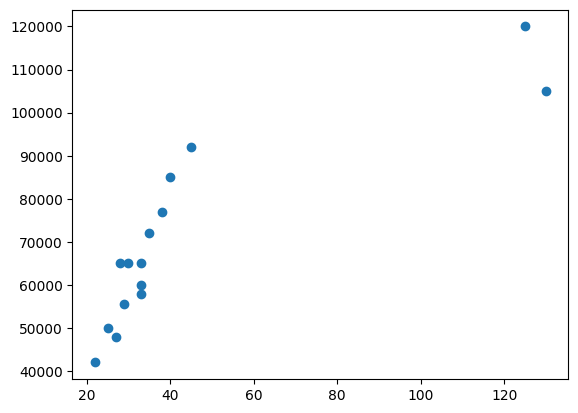

In [ ]:
plt.scatter(df['age'], df['salary'])
plt.show()

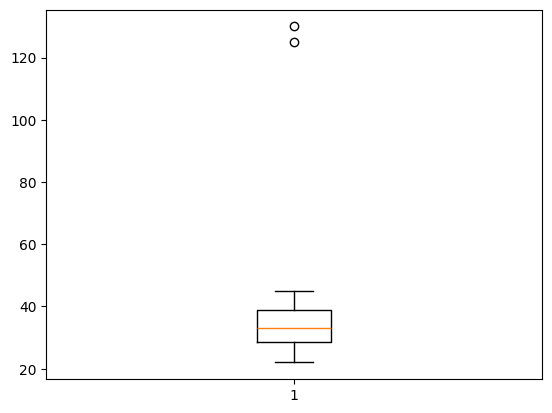

In [ ]:
plt.boxplot(df['age'])
plt.show()

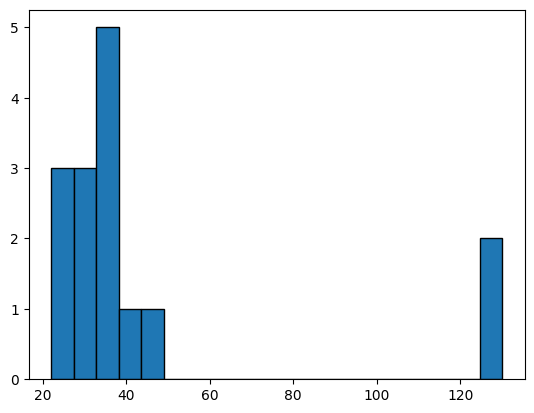

In [ ]:
plt.hist(df['age'], bins=20, edgecolor="black")
plt.show()

In [ ]:
df = df.drop(iqr_out.index)
print(df)

     age   salary  experience
0   25.0  50000.0         2.0
2   30.0  65000.0         7.0
3   22.0  42000.0         3.0
4   40.0  85000.0        12.0
5   33.0  60000.0         1.0
6   35.0  72000.0         8.0
7   28.0  65000.0         4.0
9   33.0  58000.0         6.0
10  33.0  65000.0         6.0
11  45.0  92000.0        18.0
12  27.0  48000.0         6.0
13  38.0  77000.0         5.0
14  29.0  55600.0         5.0


# Exp-4: Feature Engineering

In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [358]:
data = {
'experience': [1, 2, 5, 8, 10, 3, 12, 4, 7, 15, 2, 6, 9, 11, 4],
'education': ['UG', 'PG', 'PHD', 'PG', 'PHD', 'UG', 'PHD', 'PG', 'UG', 'PHD', 'PG', 'UG', 'PG', 'PHD', 'UG'],
'city': ['Chennai', 'Coimbatore', 'Madurai', 'Trichy', 'Salem', np.nan, 'Coimbatore', 'Madurai', 'Trichy', 'Salem', 'Chennai', 'Coimbatore', 'Madurai', 'Trichy', 'Salem'],
'salary': [35000, 45000, 75000, 85000, 120000, 40000, 140000, 60000, 55000, 180000, 42000, 52000, 95000, 130000, 48000]
}

df = pd.DataFrame(data)
print(df.head())

   experience education        city  salary
0           1        UG     Chennai   35000
1           2        PG  Coimbatore   45000
2           5       PHD     Madurai   75000
3           8        PG      Trichy   85000
4          10       PHD       Salem  120000


In [359]:
df = df.fillna(df.mode(numeric_only=False).iloc[0])
print(df)

    experience education        city  salary
0            1        UG     Chennai   35000
1            2        PG  Coimbatore   45000
2            5       PHD     Madurai   75000
3            8        PG      Trichy   85000
4           10       PHD       Salem  120000
5            3        UG  Coimbatore   40000
6           12       PHD  Coimbatore  140000
7            4        PG     Madurai   60000
8            7        UG      Trichy   55000
9           15       PHD       Salem  180000
10           2        PG     Chennai   42000
11           6        UG  Coimbatore   52000
12           9        PG     Madurai   95000
13          11       PHD      Trichy  130000
14           4        UG       Salem   48000


In [360]:
sample = pd.get_dummies(df, columns=['experience', 'education', 'city'], dtype=int)

x = sample.drop(columns=["salary"])
y = sample["salary"]

mi = mutual_info_regression(x, y)
result = pd.Series(mi, index=x.columns).sort_values(ascending=False)
print(result)

education_PHD      4.120361e-01
education_UG       2.298692e-01
city_Madurai       7.122100e-02
city_Chennai       5.476190e-02
experience_1       4.444444e-02
experience_15      4.444444e-02
experience_8       2.222222e-02
experience_5       2.222222e-02
city_Trichy        1.221001e-03
experience_6       4.440892e-16
experience_7       2.220446e-16
experience_3       2.220446e-16
experience_12      2.220446e-16
experience_11      2.220446e-16
experience_9       2.220446e-16
experience_4       0.000000e+00
experience_2       0.000000e+00
experience_10      0.000000e+00
education_PG       0.000000e+00
city_Coimbatore    0.000000e+00
city_Salem         0.000000e+00
dtype: float64


In [361]:
scaler = StandardScaler()
scaled = scaler.fit_transform(sample)

In [362]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled)
df_pca = pd.DataFrame(pca_features, columns=["PCA1", "PCA2"])
print(df_pca.head())

       PCA1      PCA2
0 -2.481832 -1.394216
1 -1.648730  0.936175
2  1.356117  1.434955
3 -0.341078  1.689423
4  3.015405 -0.750694


In [363]:
def categorize(years):
    if years < 3: return "Junior"
    elif 3 <= years <=6: return "Mid-level"
    else: return "Senior"
df['exp_category'] = df['experience'].apply(categorize)
print(df.head())

   experience education        city  salary exp_category
0           1        UG     Chennai   35000       Junior
1           2        PG  Coimbatore   45000       Junior
2           5       PHD     Madurai   75000    Mid-level
3           8        PG      Trichy   85000       Senior
4          10       PHD       Salem  120000       Senior


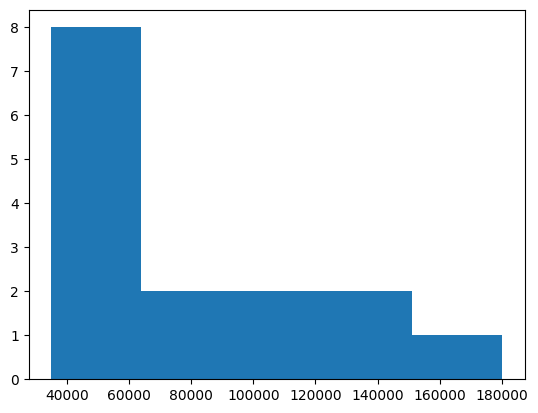

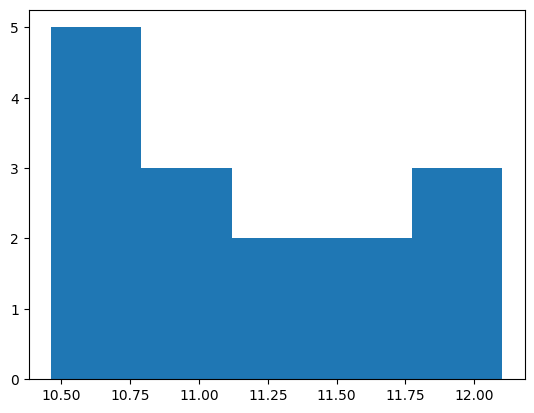

In [364]:
df["log_salary"] = np.log(df["salary"])

plt.hist(df["salary"], bins=5)
plt.show()
plt.hist(df["log_salary"], bins=5)
plt.show()

# Exp-5A: Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = {
    'Age': [22, 25, 30, 34, 38, 42, 45, 48, 52, 55, 60, 63, 68, 72, 78],
    'Glucose Level': [82, 88, 85, 92, 90, 96, 101, 98, 105, 112, 108, 115, 121, 118, 125]
}
df = pd.DataFrame(data)
print(df.head())

   Age  Glucose Level
0   22             82
1   25             88
2   30             85
3   34             92
4   38             90


In [ ]:
X = df.drop(columns=['Glucose Level'])
y = df['Glucose Level']
print(X)
print(y)

    Age
0    22
1    25
2    30
3    34
4    38
5    42
6    45
7    48
8    52
9    55
10   60
11   63
12   68
13   72
14   78
0      82
1      88
2      85
3      92
4      90
5      96
6     101
7      98
8     105
9     112
10    108
11    115
12    121
13    118
14    125
Name: Glucose Level, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10, 1)
(5, 1)
(10,)
(5,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print(list(y_test))
print(y_pred)

[112, 115, 82, 118, 96]
[106.92114914 113.16687042  81.1575489  120.19330685  96.77185208]


In [ ]:
n = int(input("Enter age: "))
print(model.predict([[n]]))

Enter age: 60
[110.82472494]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mse, r2, model.intercept_, model.coef_)

7.0542328990964105 0.9619594860920168 63.98181540342299 [0.78071516]


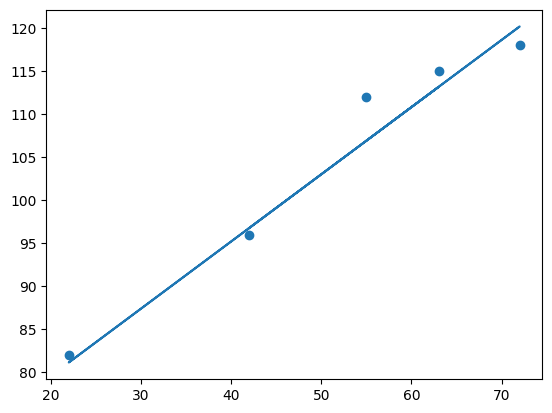

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.show()

# Exp-5B: Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
data = {
    'Age': [22, 25, 30, 34, 38, 42, 45, 48, 52, 55, 60, 63, 68, 72, 78],
    'Diabetic': [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)
print(df.head())

   Age  Diabetic
0   22         0
1   25         0
2   30         0
3   34         0
4   38         0


In [ ]:
X = df.drop(columns=["Diabetic"])
y = df["Diabetic"]
print(X)
print(y)

    Age
0    22
1    25
2    30
3    34
4    38
5    42
6    45
7    48
8    52
9    55
10   60
11   63
12   68
13   72
14   78
0     0
1     0
2     0
3     0
4     0
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    1
14    1
Name: Diabetic, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
print(list(y_test))
print(y_pred)

[1, 1, 0, 1, 0]
[1 1 0 1 0]


In [ ]:
n = int(input("Enter age: "))
print(model.predict([[n]]))

Enter age: 60
[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(acc)
print(cm)
print(model.intercept_)
print(model.coef_)

1.0
[[2 0]
 [0 3]]
[-14.029265]
[[0.30397288]]


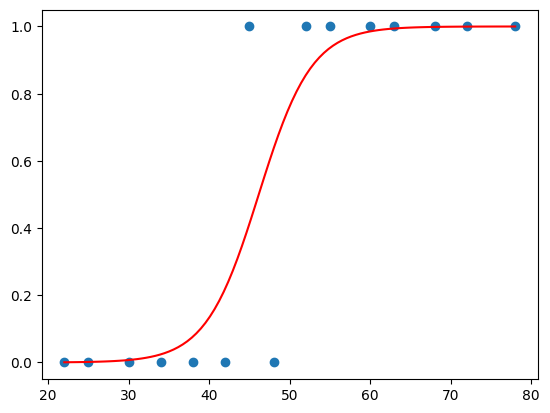

In [ ]:
plt.scatter(X, y)

age_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
age_df = pd.DataFrame(age_range, columns=["Age"])
probs = model.predict_proba(age_df)[:,1]

plt.plot(age_range, probs, color="red")
plt.show()

# Exp-6A: Decision Tree

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
data = pd.read_csv("weatherHistory.csv")
df = pd.DataFrame(data)
print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [ ]:
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna(df.mode(numeric_only=False).iloc[0])
print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
label = LabelEncoder()
for i in cat_cols:
    df[i] = label.fit_transform(df[i])
print(df.head())

   Formatted Date  Summary  Precip Type  Temperature (C)  \
0            2159       19            0         9.472222   
1            2160       19            0         9.355556   
2            2161       17            0         9.377778   
3            2162       19            0         8.288889   
4            2163       17            0         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13   
1                   259.0          15.8263         0.0               1015.63   
2                   204.0          14.

In [ ]:
X = df.drop("Summary", axis=1)
y = df["Summary"]
print(X)
print(y)

       Formatted Date  Precip Type  Temperature (C)  Apparent Temperature (C)  \
0                2159            0         9.472222                  7.388889   
1                2160            0         9.355556                  7.227778   
2                2161            0         9.377778                  9.377778   
3                2162            0         8.288889                  5.944444   
4                2163            0         8.755556                  6.977778   
...               ...          ...              ...                       ...   
96448           93711            0        26.016667                 26.016667   
96449           93712            0        24.583333                 24.583333   
96450           93713            0        22.038889                 22.038889   
96451           93714            0        21.522222                 21.522222   
96452           93715            0        20.438889                 20.438889   

       Humidity  Wind Speed

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred = model.predict(X_test)
print(list(y_test[:10]))
print(y_pred[:10])

[17, 17, 17, 18, 17, 17, 17, 17, 17, 19]
[19 19 19 17 17 17 17 17 18 17]


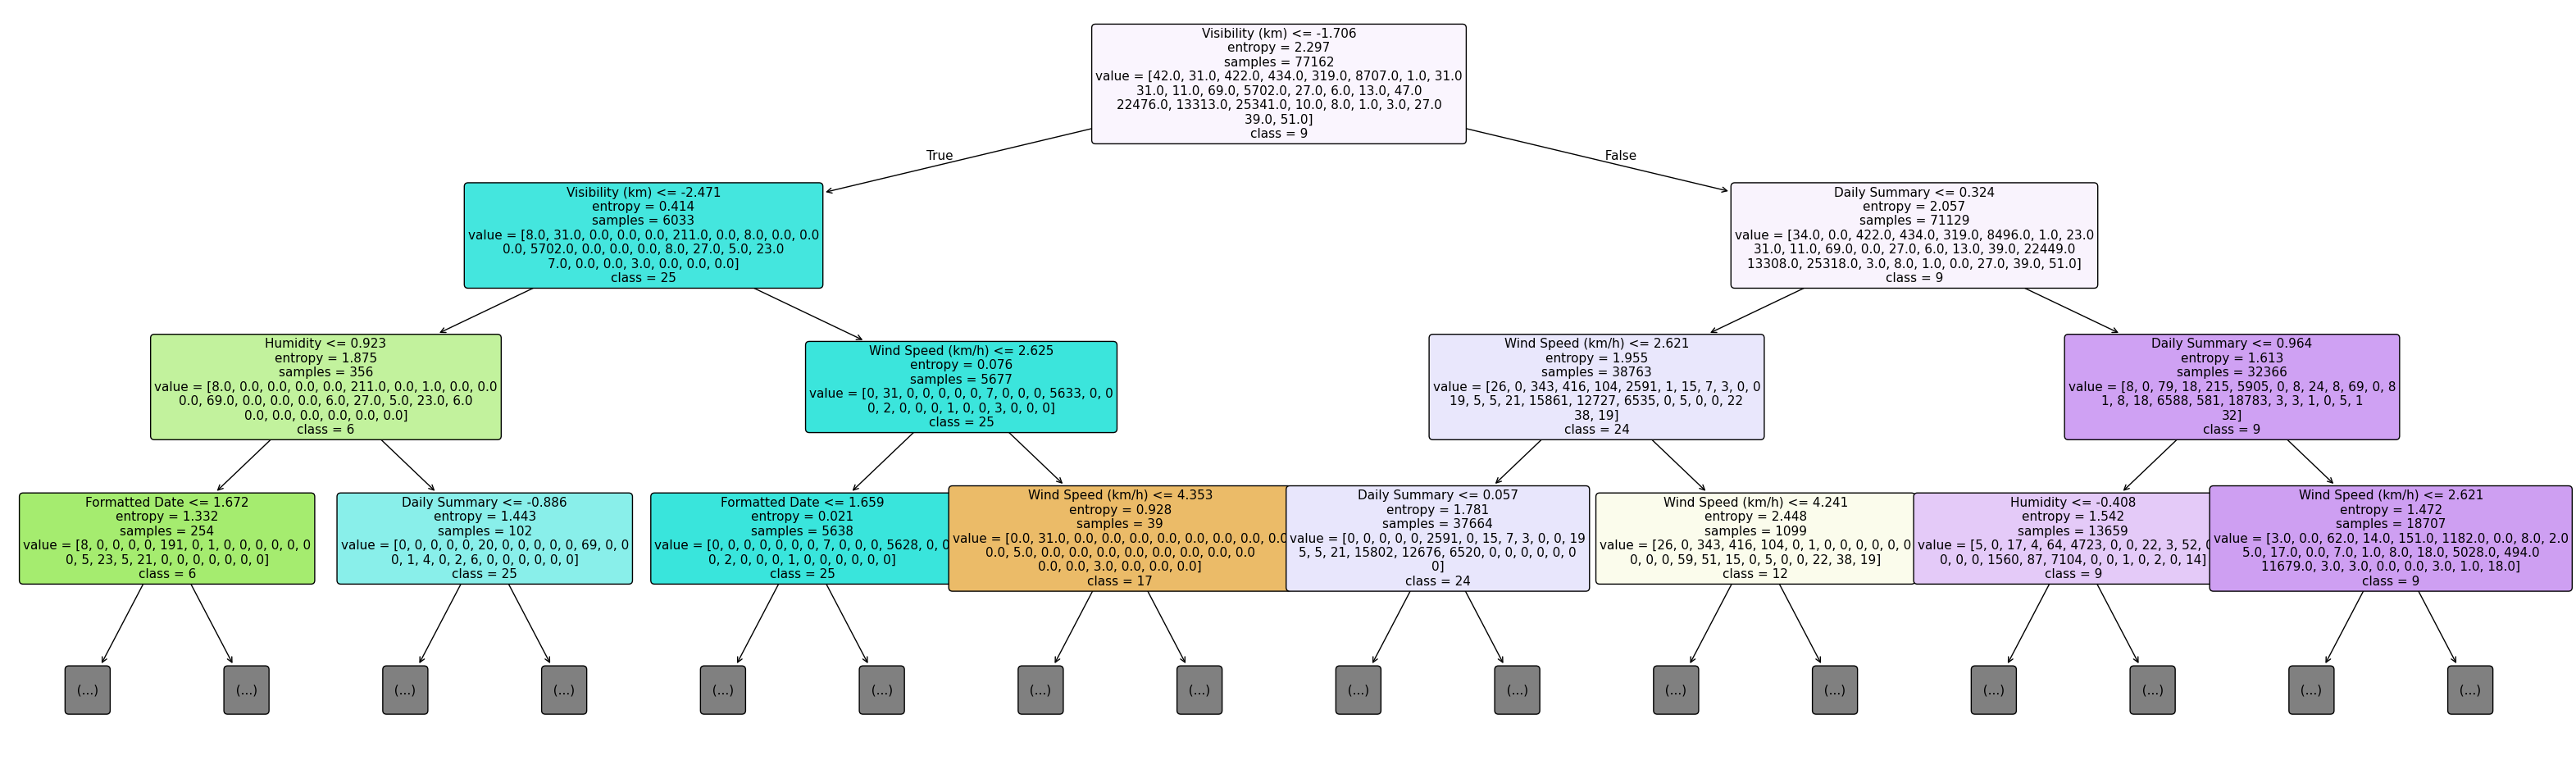

In [ ]:
plt.figure(figsize=(40,12))
plot_tree(model, feature_names=X.columns, class_names=[str(i) for i in y.unique()], filled=True, rounded=True, max_depth=3, fontsize=11)
plt.show()

In [ ]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(acc)
print(cm)
print(cr)

0.6347001192265823
[[   6    0    0    2    2    2    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    4    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0   37   27   24    0    0    0    0    0    0    0    0
     0    0    4    1    0    0    0    0    0    0    0    0]
 [   0    0    0   29   52    6    0    0    0    0    0    0    0    0
     0    0    7    0    0    0    0    0    0    0    0    0]
 [   3    0    0   18    1   39    0    0    0    0    1    0    0    0
     0    0    0    0    4    0    0    1    0    0    0    0]
 [   0    0    0    0    0    0 1311    0    1    0    0    1    1    0
     0    0  178   77  614    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Exp-6B: K-Means Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [ ]:
data = pd.read_csv("Iris.csv")
df = pd.DataFrame(data)
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna(df.mode(numeric_only=False).iloc[0])
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
X = data.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-1.72054204 -0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.69744751 -1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.67435299 -1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.65125846 -1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.62816394 -1.02184904  1.26346019 -1.3412724  -1.31297673]]


In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[749.9999999999998, 273.7275610947794, 177.05608895062977, 150.65344781779098, 124.05040365494744, 100.82425364004882, 92.5786915909479, 97.64648261569884, 81.83818514928078, 69.2370593946661]


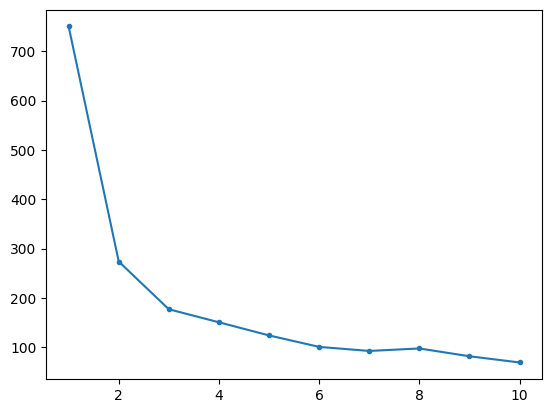

In [ ]:
plt.plot(range(1,11), wcss, marker=".")
plt.show()

In [ ]:
kneedle = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
K = kneedle.elbow
print(K)

3


In [ ]:
kmeans = KMeans(n_clusters=K, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


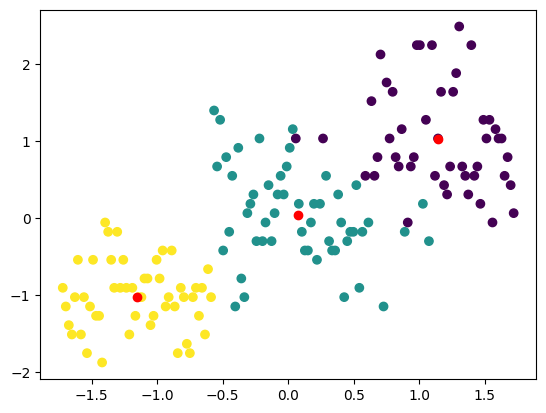

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], color="red")
plt.show()

In [ ]:
cols = X.columns
print(cols)
sample_df = pd.DataFrame([[1, 5.1, 3.5, 1.4, 0.2]], columns=['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
sample_scaled = scaler.transform(sample_df)
pred = kmeans.predict(sample_scaled)
print(pred)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')
[2]


# Exp-7: SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

In [ ]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)
print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(list(y_test))
print(y_pred)

[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0]
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


In [ ]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(acc)
print(cm)
print(cr)

0.9736842105263158
[[41  2]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



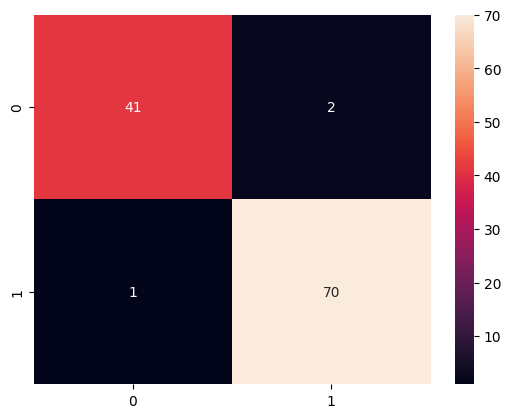

In [ ]:
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

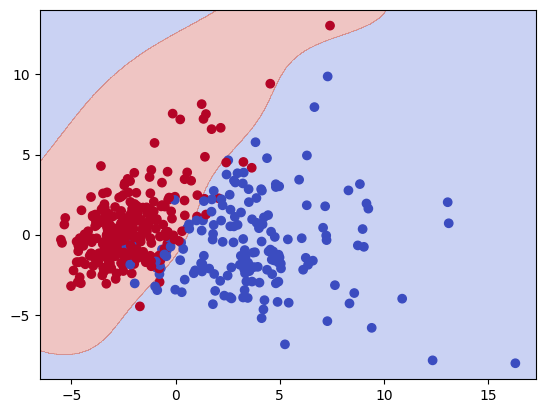

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
model_2d = SVC(kernel='rbf').fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:,0].min() - 1, X_train_pca[:,0].max() + 1
y_min, y_max = X_train_pca[:,1].min() - 1, X_train_pca[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap="coolwarm")
plt.show()

# Exp-8: PCA

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [254]:
data = {
    'Age': [25, 30, 35, 40, 45, 22, 28, 33, 38, 43, 20, 26, 31, 36, 41],
    'Salary': [50000, 60000, 70000, 80000, 90000, 48000, 55000, 65000, 75000, 85000, 45000, 52000, 62000, 72000, 82000],
    'Spending_Score': [30, 45, 50, 65, 80, 25, 40, 55, 70, 85, 20, 35, 50, 60, 75]
}
df = pd.DataFrame(data)
print(df.head())

   Age  Salary  Spending_Score
0   25   50000              30
1   30   60000              45
2   35   70000              50
3   40   80000              65
4   45   90000              80


In [255]:
X = df.drop("Spending_Score", axis=1)
y = df["Spending_Score"]
print(X.head())
print(y.head())

   Age  Salary
0   25   50000
1   30   60000
2   35   70000
3   40   80000
4   45   90000
0    30
1    45
2    50
3    65
4    80
Name: Spending_Score, dtype: int64


In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [257]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [258]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

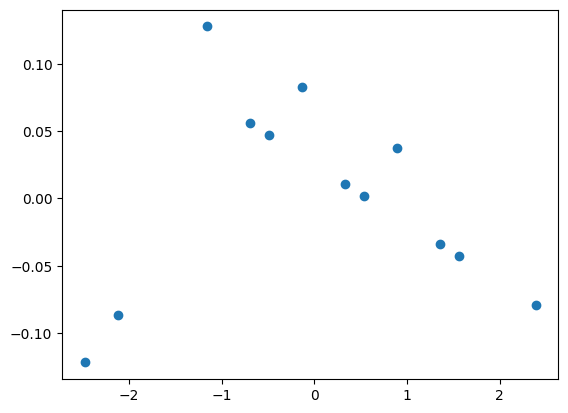

In [259]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1])
plt.show()

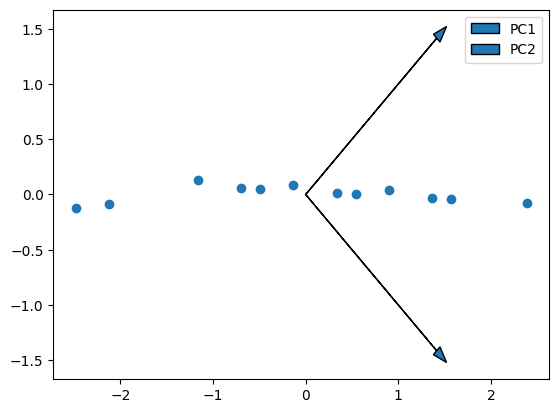

In [261]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1])
for i, c in enumerate(pca.components_):
    plt.arrow(0, 0, c[0]*2, c[1]*2, head_width=0.1, label=f"PC{i+1}")
plt.legend()
plt.show()

# Exp-9A: Lasso & Ridge Regularization

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [263]:
house = fetch_california_housing()
df = pd.DataFrame(house.data, columns=house.feature_names)
df["HouseVals"] = house.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseVals  
0    -122.23      4.526  
1    -122.22      3.585  
2    -122.24      3.521  
3    -122.25      3.413  
4    -122.25      3.422  


In [264]:
X = df.drop("HouseVals", axis=1)
y = df["HouseVals"]
print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseVals, dtype: float64


In [265]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [266]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [267]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

LinearRegression()

In [268]:
ridge = Ridge(1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [277]:
lasso = Lasso(0.1)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [289]:
y_pred_linear = linear.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

print(mean_squared_error(y_test, y_pred_linear))
print(mean_squared_error(y_test, y_pred_ridge))
print(mean_squared_error(y_test, y_pred_lasso))

0.5558915986952442
0.5558548589435971
0.6796290284328825


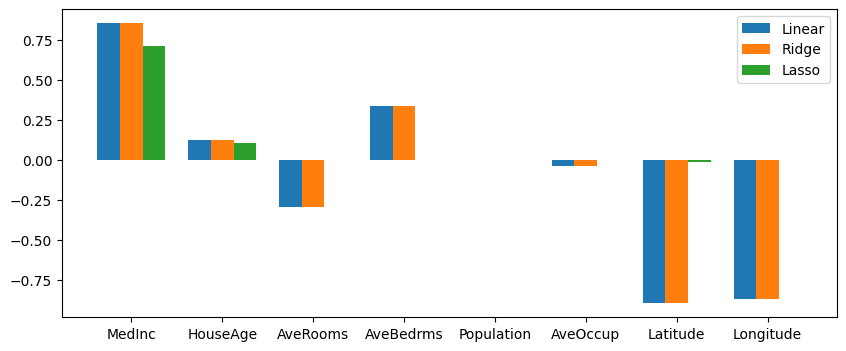

In [301]:
features = house.feature_names
x = np.arange(len(features))

plt.figure(figsize=(10,4))
plt.bar(x-0.25, linear.coef_, 0.25, label='Linear')
plt.bar(x, ridge.coef_, 0.25, label='Ridge')
plt.bar(x+0.25, lasso.coef_, 0.25, label='Lasso')

plt.xticks(x, features)
plt.legend()
plt.show()

# Exp-9B: Ensemble Model

In [302]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

In [304]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [305]:
X = df.drop("target", axis=1)
y = df["target"]
print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [306]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [307]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [309]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [310]:
rf_pred = rf_model.predict(X_test_scaled)
print(rf_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


In [311]:
ada_model = AdaBoostClassifier(n_estimators=10, random_state=42, learning_rate=0.1, estimator=DecisionTreeClassifier(max_depth=1))
ada_model.fit(X_train_scaled, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.1, n_estimators=10, random_state=42)

In [312]:
ada_pred = ada_model.predict(X_test_scaled)
print(ada_pred)

[1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


In [315]:
ensemble = VotingClassifier(
    estimators = [("rf", rf_model), ("ada", ada_model)],
    voting = "soft"
)
ensemble.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('ada',
                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                 learning_rate=0.1,
                                                 n_estimators=10,
                                                 random_state=42))],
                 voting='soft')

In [317]:
ensemble_pred = ensemble.predict(X_test_scaled)
print(ensemble_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


In [334]:
rf_acc = accuracy_score(y_test, rf_pred)
ada_acc = accuracy_score(y_test, ada_pred)
ensemble_acc = accuracy_score(y_test, ensemble_pred)
print(rf_acc)
print(ada_acc)
print(ensemble_acc)

1.0
0.9777777777777777
1.0


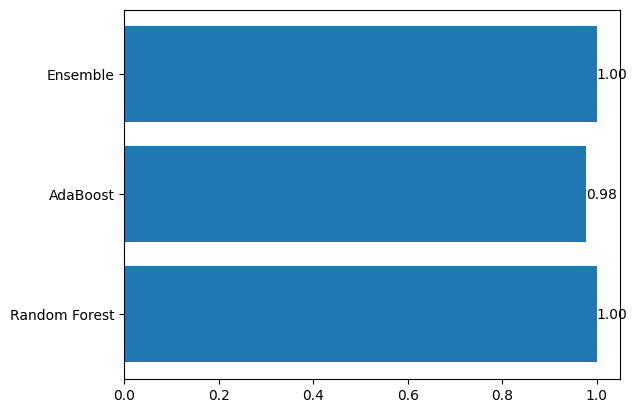

In [355]:
models = ["Random Forest", "AdaBoost", "Ensemble"]
accuracies = [rf_acc, ada_acc, ensemble_acc]

plt.barh(models, accuracies)
for i, a in enumerate(accuracies):
    plt.text(a, i, f"{a:.2f}", va="center")
plt.show()

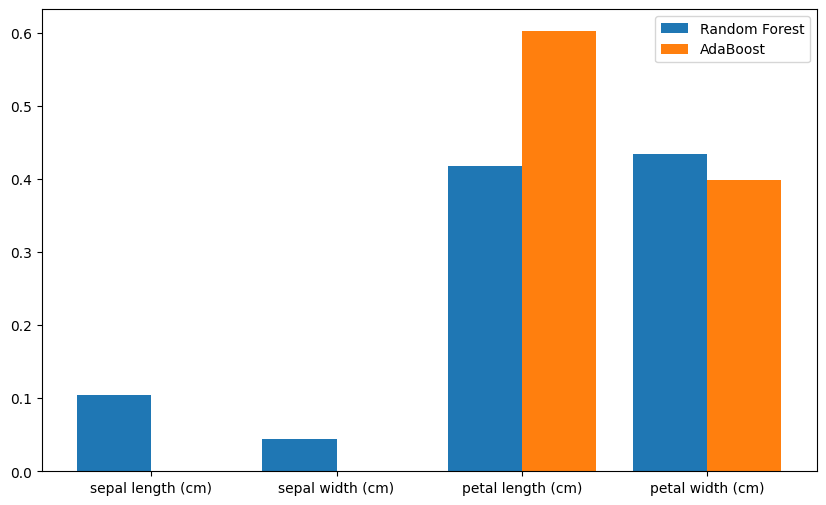

In [327]:
x = np.arange(len(iris.feature_names))
plt.figure(figsize=(10,6))
plt.bar(x-0.2, rf_model.feature_importances_, 0.4, label="Random Forest")
plt.bar(x+0.2, ada_model.feature_importances_, 0.4, label="AdaBoost")

plt.xticks(x, iris.feature_names)
plt.legend()
plt.show()

# Exp-10: Hyperparameters

In [372]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingGridSearchCV, RandomizedSearchCV
from skopt import BayesSearchCV

In [373]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [374]:
X = df.drop("target", axis=1)
y = df["target"]
print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [375]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [388]:
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

In [401]:
manual = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
manual.fit(X_train, y_train)
y_pred = manual.predict(X_test)
manual_acc = accuracy_score(y_test, y_pred)

In [402]:
random = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=10, cv=3)
random.fit(X_train, y_train)
y_pred = random.predict(X_test)
random_acc = accuracy_score(y_test, y_pred)
print(random.best_params_)
print(random.best_score_)

{'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 5}
0.9523809523809524


In [403]:
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
grid_acc = accuracy_score(y_test, y_pred)
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
0.9523809523809524


In [404]:
half = HalvingGridSearchCV(RandomForestClassifier(random_state=42), param_grid, factor=2, cv=3)
half.fit(X_train, y_train)
y_pred = half.predict(X_test)
half_acc = accuracy_score(y_test, y_pred)
print(half.best_params_)
print(half.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.9444444444444445


In [405]:
bayes = BayesSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=10, cv=3)
bayes.fit(X_train, y_train)
y_pred = bayes.predict(X_test)
bayes_acc = accuracy_score(y_test, y_pred)
print(bayes.best_params_)
print(bayes.best_score_)

OrderedDict({'max_depth': None, 'min_samples_split': 10, 'n_estimators': 10})
0.9523809523809524


In [406]:
print(manual_acc)
print(random_acc)
print(grid_acc)
print(half_acc)
print(bayes_acc)

1.0
1.0
1.0
1.0
1.0


# Exp-11A: Bayes Search Model

In [443]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.metrics import classification_report


In [444]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [446]:
X = df.drop("target", axis=1)
y = df["target"]
print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [447]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [448]:
model = SVC()

In [449]:
search = {
    'C': Real(1e-6, 100.0, prior="log-uniform"),
    'gamma': Real(1e-6, 1.0, prior="log-uniform"),
    'kernel': Categorical(['linear', 'rbf', 'poly'])
}

In [451]:
bayes = BayesSearchCV(estimator=model, search_spaces=search, n_iter=30, cv=5, n_jobs=-1, scoring="accuracy", random_state=42)
bayes.fit(X_train, y_train)

BayesSearchCV(cv=5, estimator=SVC(), n_iter=30, n_jobs=-1, random_state=42,
              scoring='accuracy',
              search_spaces={'C': Real(low=1e-06, high=100.0, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=1e-06, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('linear', 'rbf', 'poly'), prior=None)})

In [452]:
print(bayes.best_params_)
print(bayes.best_score_)
y_pred = bayes.predict(X_test)
cr = classification_report(y_test, y_pred)
print(cr)

OrderedDict({'C': 44.037625157309144, 'gamma': 0.01598558991826748, 'kernel': 'poly'})
0.9714285714285715
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# Exp-11B: Forecasting Time-Series Data

In [503]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [504]:
data = pd.read_csv("airline-passengers.csv")
df = pd.DataFrame(data)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


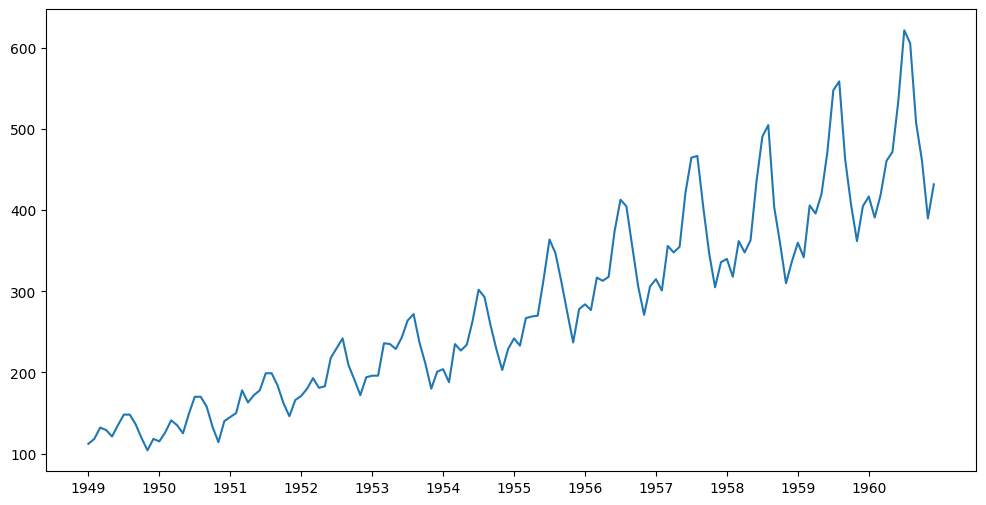

In [514]:
plt.figure(figsize=(12,6))
plt.plot(df["Month"], df["Passengers"])
plt.xticks(df["Month"][::12], [x[:4] for x in df["Month"][::12]])
plt.show()

In [506]:
def adf_test(series):
    result = adfuller(series)
    print("ADF stats:", result[0])
    print("p-vals:", result[1])
    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")
adf_test(df["Passengers"])

ADF stats: 0.8153688792060498
p-vals: 0.991880243437641
Non-Stationary


In [507]:
df['Passengers'] = df['Passengers'].astype(float)
data_diff = df[['Passengers']].diff().dropna()
adf_test(data_diff)

ADF stats: -2.8292668241700047
p-vals: 0.05421329028382478
Non-Stationary


In [508]:
data_log = np.log(df['Passengers'])
data_log_diff = data_log.diff().dropna()
adf_test(data_log_diff)

ADF stats: -2.717130598388114
p-vals: 0.07112054815086184
Non-Stationary


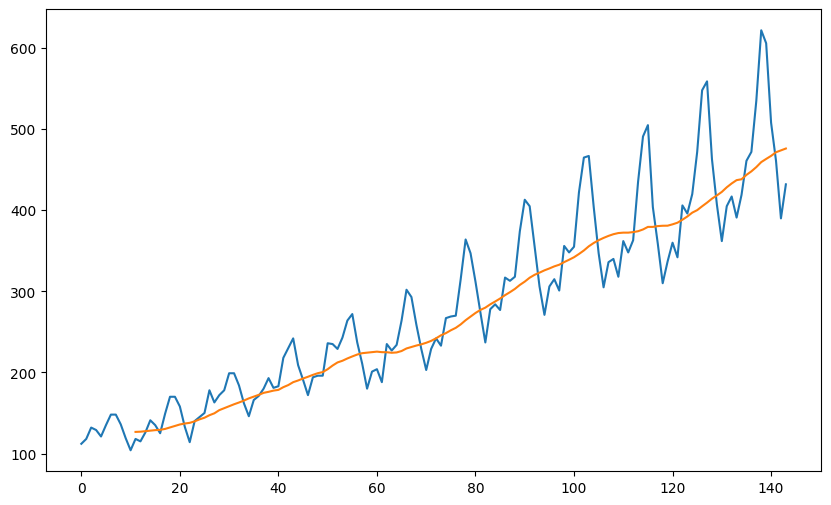

In [509]:
sma = df['Passengers'].rolling(12).mean()
plt.figure(figsize=(10,6))
plt.plot(df['Passengers'])
plt.plot(sma)
plt.show()

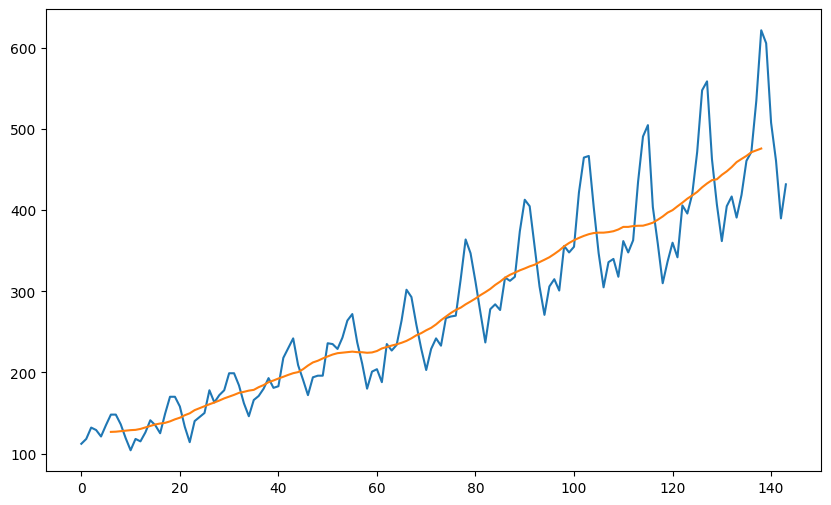

In [510]:
cma = df['Passengers'].rolling(12, center=True).mean()
plt.figure(figsize=(10,6))
plt.plot(df['Passengers'])
plt.plot(cma)
plt.show()

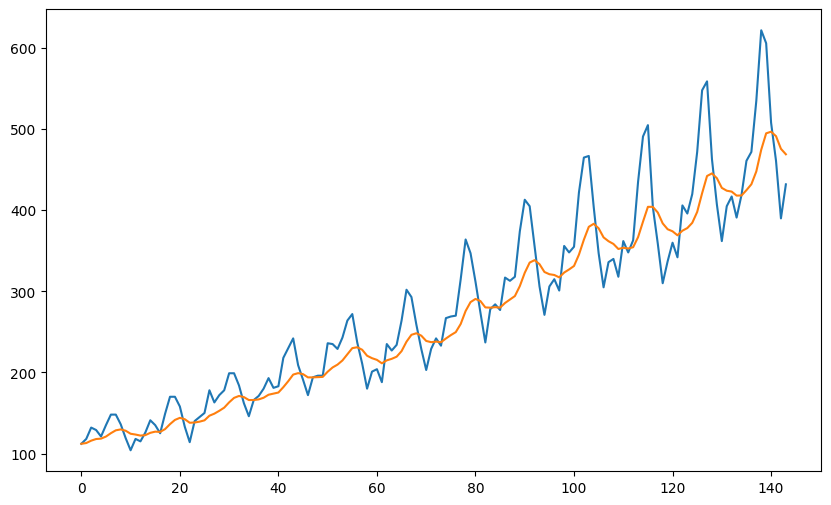

In [511]:
ema = df['Passengers'].ewm(span=12, adjust=False).mean()
plt.figure(figsize=(10,6))
plt.plot(df['Passengers'])
plt.plot(ema)
plt.show()

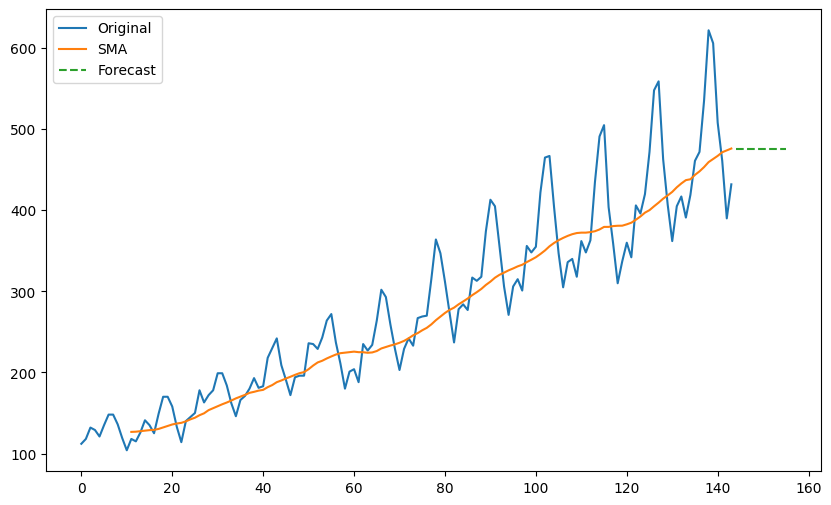

In [512]:
forecast = pd.Series(
    [sma.dropna().iloc[-1]]*12,
    index = range(len(df), len(df)+12)
)
plt.figure(figsize=(10,6))
plt.plot(df['Passengers'], label='Original')
plt.plot(sma, label='SMA')
plt.plot(forecast, linestyle='--', label='Forecast')

plt.legend()
plt.show()

# ~ FIN